# Week 5: Karpathy and Flowers Dataset

## Objective
In this notebook, I worked with the TensorFlow Flowers dataset and implemented a transfer learning image classification pipeline using EfficientNetB0. The main goal was to apply Andrej Karpathy's "Overfit One Batch" sanity check before training on the full dataset.

## Tasks Completed
- Loaded and explored the Flowers dataset (5 flower classes).
- Visualized sample images and labels.
- Built a transfer learning model using EfficientNetB0 with a frozen feature extractor.
- Performed Karpathy's overfit-one-batch test using only two training images.
- Verified that the model could memorize the two images, achieving 100% accuracy and reducing the loss from 1.3561 to 0.0035.
- Trained the model on the full Flowers dataset.
- Evaluated model performance on the validation dataset.

## Results

### Overfit-One-Batch Test
- Initial Loss: 1.3561
- Final Loss: 0.0035
- Accuracy: 100%

### Full Dataset Training
- Epoch 1: Training Accuracy = 99.80%, Validation Accuracy = 100%
- Epoch 2: Training Accuracy = 100%, Validation Accuracy = 100%

### Final Evaluation
- Validation Accuracy: 100%
- Validation Loss: 0.0010

## Key Learning
The overfit-one-batch sanity check is a simple but powerful debugging technique. If a model cannot memorize a tiny dataset, there is likely an issue with the data pipeline, labels, model architecture, loss function, or optimizer. Passing this test confirms that the training setup is functioning correctly before running larger experiments.

Imports

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Download Flowers Dataset

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

print(data_dir)

/root/.keras/datasets/flower_photos


Load Dataset

In [3]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print(class_names)

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.
['flower_photos']


Show 20 Images

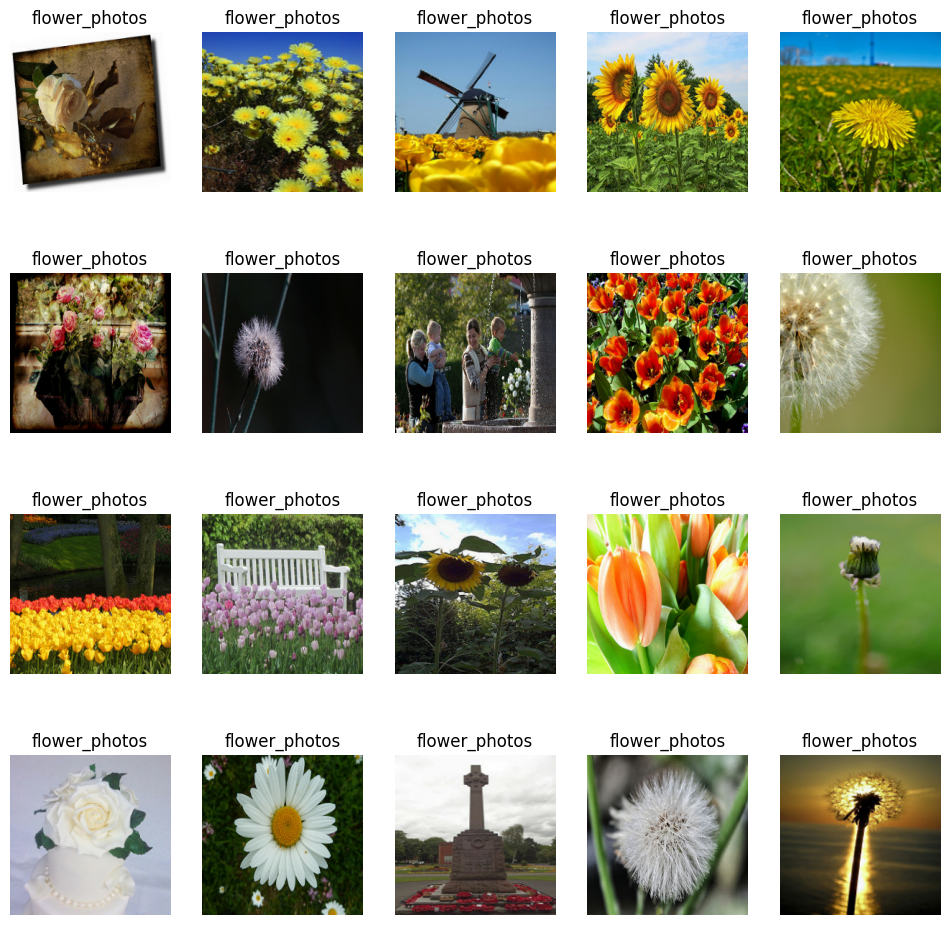

In [4]:
plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):

    for i in range(20):

        plt.subplot(4,5,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

Create Tiny Dataset (2 Images)

In [5]:
for images, labels in train_ds.take(1):

    tiny_images = images[:2]

    tiny_labels = labels[:2]

print("Labels:", tiny_labels.numpy())
print("Image Shape:", tiny_images.shape)

Labels: [0 0]
Image Shape: (2, 224, 224, 3)


Visualize Tiny Images

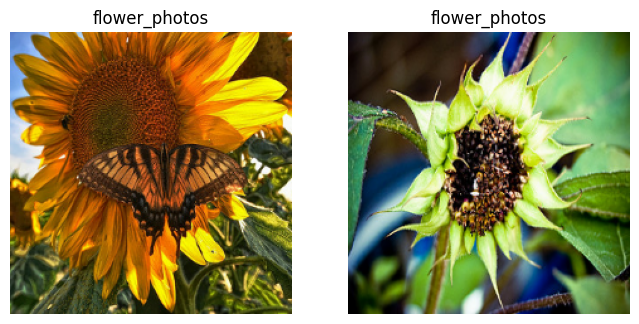

In [6]:
plt.figure(figsize=(8,4))

for i in range(2):

    plt.subplot(1,2,i+1)

    plt.imshow(tiny_images[i].numpy().astype("uint8"))

    plt.title(class_names[tiny_labels[i]])

    plt.axis("off")

plt.show()

Build EfficientNetB0

In [7]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

Build Model

In [8]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        5,
        activation="softmax"
    )

])

Compile

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Verify Model

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

Create Tiny Dataset

In [11]:
tiny_ds = tf.data.Dataset.from_tensor_slices(
    (tiny_images, tiny_labels)
)

tiny_ds = tiny_ds.batch(2).repeat()

Check Loss Before Training

In [12]:
preds = model(tiny_images)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

loss = loss_fn(tiny_labels, preds)

print("Initial Loss:", loss.numpy())

Initial Loss: 1.356135


Karpathy Overfit Test

In [13]:
history = model.fit(
    tiny_ds,
    epochs=50,
    steps_per_epoch=1,
    verbose=1
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step - accuracy: 0.0000e+00 - loss: 1.3476
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 1.0735
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.8165
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.6225
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.4611
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.3494
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.3462
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1711
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.1433
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1025
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0769
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.08

Rebuild a fresh model

In [15]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(5, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Train on the full dataset

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2
)

Epoch 1/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 294ms/step - accuracy: 0.9980 - loss: 0.0764 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 2/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0010


Evaluate

In [17]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 1.0000 - loss: 0.0010
Validation Accuracy: 1.0
